# Rename-proof logic consensus and error-type tests

This notebook is a demo of **experiment 8, iteration 3**. The experiment builds **gold-free metrics** for natural-language → first-order-logic (NL→FOL) translation and tests them.

**The problem.** A sentence has many correct FOL translations: predicate names differ, concepts are split differently, and equivalent rewrites are all fine. Gold formulas are rare. A metric has to judge a candidate formula **without a gold formula**.

**The method under test: PEER_HYB cross-family consensus.** Other model families translate the same sentence. These translations are the *peers*. A candidate *agrees* with a peer if the z3 solver proves the two formulas equivalent under a mapping between their vocabularies. Two mappings are tried:
* **ALIGN** maps names by string similarity (e.g. `Sad` ↔ `IsSad`).
* **NF-anchored** is *name-free*: it maps predicates by their structural role, so a formula whose predicates were renamed (`Food` → `Nutrient`) can still match.

**HYB = ALIGN OR NF.** The score is `c_score = 1 − (#agreeing peers / #peers)`. A **higher score means the candidate is more likely an ERROR**.

**What the experiment found:**
* *Part A (dataset E, real outputs of 10+ LLM generators, prover/panel labels).* HYB (AUROC 0.738) did **not** beat plain ALIGN (0.741). HYB's extra agreements are often wrong: 39% are label-discordant, against 13% for ALIGN's agreements. No variant passed the pre-registered rule "rename false-alarm rate ≤ 0.10", so nothing was frozen and ALIGN is kept.
* *Part B (PERTURB).* 27 metrics were scored on 4,234 typed mutants of trusted formulas (NEG, QUANT, ADD, DROP, SWAP, …) plus meaning-preserving controls. The results are per-error-type sensitivity, DOWN/UP polarity, and rename invariance.

**What `method.py` does.** It is the experiment's driver script. `run()` executes 13 resumable stages. They need the full repository, a GPU and an OpenRouter key, so the notebook does not run them. `build_output()` joins the stage results into `method_out.json`. The notebook runs `build_output()` on a small slice of the real stage outputs (`mini_demo_data.json`: 4 sentences of dataset E with 56 candidates and their z3 pair verdicts, 2 PERTURB bases with 31 mutants and controls, and 8 screen items). It then re-derives and visualises the headline measurements.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# ---- original method.py import block (unchanged)
import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

from loguru import logger

# ---- additional imports for the notebook (analysis + visualisation)
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print({k: (len(v) if isinstance(v, (list, dict)) else type(v).__name__) for k, v in data.items() if k != "about"})

Mini slice of the experiment-8 meta-evaluation (PEER_HYB consensus + PERTURB per-error-type sensitivity). Each key mirrors one input file of method.py build_output(); orientation: higher score = more likely ERROR.
{'selection': 10, 'analysis_perturb_metrics': 27, 'prereg_hyb_sha256': 'str', 'prereg_perturb_sha256': 'str', 'E_blind': 53, 'per_item_hyb_E': 53, 'pairs_E': 383, 'perturb_scores': 31, 'perturb_rows': 29, 'per_item_screen_hyb': 8, 'screen_adjudicated_labels': 3, 'invariance_items': 3, 'screen_items': 4, 'screen_probes': 2}


## Configuration

All tunable parameters are here. The mini data holds 4 dataset-E sentences, one per complexity stratum (CTRL = short control, EXC = exceptions, L20 = ≥20 words, L25 = ≥25 words). Each was drawn at random among sentences with at least 3 CORRECT and 3 ERROR candidates, so an AUROC is defined; the rule never looks at scores. It also holds 2 PERTURB bases and 8 screen rows. The values below use **all of the mini data**. Everything is precomputed-verdict arithmetic, so this takes seconds. The original full-run sizes are given in the comments.

In [5]:
N_E_SENTENCES = 4        # dataset-E sentences to include (max 4 in the mini data; original: all 700 sentences / 8,507 rows)
N_PERTURB_BASES = 2      # PERTURB bases (each with all its mutants + controls; max 2 here; original: 300 bases / 5,402 rows)
N_SCREEN_ROWS = 8        # screen items + exp-D rewrites + probes (max 8 here; original: 1,870 rows)
N_PLACEBO = 20           # label permutations for the placebo AUROC (original audit: 1 permutation, seed 1)
N_BOOT = 200             # sentence-cluster bootstrap resamples for the HYB-ALIGN AUROC difference (original audit: 300)
RUN_PIPELINE = False     # True would call run(): re-executes the 13 stages via subprocess (needs the full repo, GPU, OpenRouter key)
SEED = 1

# ---- apply the size parameters: the views below stand in for the stage-output files that build_output() reads
_e_sids = list(dict.fromkeys(r["sentence_id"] for r in data["per_item_hyb_E"]))[:N_E_SENTENCES]
_p_bases = list(dict.fromkeys(u["base"] for u in data["perturb_scores"]))[:N_PERTURB_BASES]
per_item_hyb_E = [r for r in data["per_item_hyb_E"] if r["sentence_id"] in _e_sids]
pairs_E = [p for p in data["pairs_E"] if p["sentence_id"] in _e_sids]
perturb_scores = [u for u in data["perturb_scores"] if u["base"] in _p_bases]
per_item_screen_hyb = data["per_item_screen_hyb"][:N_SCREEN_ROWS]
print(f"E rows {len(per_item_hyb_E)} ({len(_e_sids)} sentences), E pair verdicts {len(pairs_E)}, "
      f"PERTURB rows {len(perturb_scores)} ({len(_p_bases)} bases), screen rows {len(per_item_screen_hyb)}")

E rows 53 (4 sentences), E pair verdicts 383, PERTURB rows 31 (2 bases), screen rows 8


## 1. Paths and logging (from `method.py`)

This is `method.py`'s module-level setup. The one change: `ROOT` is the notebook's working directory, because a notebook has no `__file__`. `PY` is the repository's venv interpreter. The stage table uses it, but it is only called when `RUN_PIPELINE=True`.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
RES = ROOT / "results"
PY = str(ROOT / ".venv" / "bin" / "python")
sys.path.insert(0, str(ROOT / "src"))

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

2

## 2. The stage pipeline (from `method.py`)

The full experiment is a chain of resumable stages. Each stage is a separate script under `src/`:

| stage | what it does |
|---|---|
| `score` | pair engine: for every candidate × peer pair of a sentence, z3 verdicts `align_eq`, `nf_eq`, `hyb_eq` (CPU) |
| `gate` | regression gate against experiment 5's frozen columns |
| `freeze_a` | **pre-registration** of the HYB/NF selection rule, frozen (sha256) *before* any label is joined |
| `part_a` | rename false alarms, over-alignment audit, selection, stratified AUROC on dataset E |
| `calib`, `api`, `cpu_b`, `gpu_b`, `s4` | the 27 PERTURB metrics: parse, pilot structural, text-side L2/L3, PEER+TEXT, self-consistency, local LLM judges, round trip, flash-lite judge, S4 stack |
| `freeze_b` | pre-registration of the PERTURB thresholds and predictions |
| `part_b`, `part_c` | per-operator × polarity sensitivity, invariance, trade-off; error-type identification |
| `tests` | unit tests of `src/consensus_lib.py` |

`DONE_MARK` protects frozen files: a stage whose mark exists is never re-run. The notebook defines `run()` unchanged but does not call it (`RUN_PIPELINE=False`). It prints the plan instead.

In [7]:
STAGES = [
    ("score", [[PY, "src/run_scoring.py", "E", "--stage", "all"], [PY, "src/run_scoring.py", "screen", "--stage", "all"]]),
    ("gate", [[PY, "src/gate_check.py"]]),
    ("freeze_a", [[PY, "src/freeze_prereg_hyb.py"]]),
    ("part_a", [[PY, "src/analyse_hyb.py"]]),
    ("calib", [[PY, "src/prep_calib.py"]]),
    ("api", [[PY, "src/run_api_perturb.py"]]),
    ("cpu_b", [[PY, "src/perturb_cpu.py"]]),
    ("gpu_b", [[PY, "src/perturb_gpu.py", "--which", "judges_disg,verb,nli"]]),
    ("s4", [[PY, "src/fit_s4_perturb.py"]]),
    ("freeze_b", [[PY, "src/freeze_prereg_perturb.py"]]),
    ("part_b", [[PY, "src/analyse_perturb.py"]]),
    ("part_c", [[PY, "src/typing_perturb.py"]]),
    ("tests", [[PY, "-m", "pytest", "-q", "-c", "pytest.ini", "tests"]]),
]
DONE_MARK = {"freeze_a": RES / "prereg_hyb.sha256", "freeze_b": RES / "prereg_perturb.sha256", "calib": ROOT / "data" / "E_calib_units.jsonl",
             "s4": RES / "s4_perturb_coefs.json"}


def run(start: str | None):
    go = start is None
    for name, cmds in STAGES:
        go = go or name == start
        if not go:
            continue
        if name in DONE_MARK and DONE_MARK[name].exists():
            logger.info(f"{name}: already done ({DONE_MARK[name].name}); frozen files are never overwritten")
            continue
        for c in cmds:
            logger.info(f"{name}: {' '.join(c[1:])}")
            subprocess.run(c, cwd=ROOT, check=True)


if RUN_PIPELINE:
    run(None)
else:  # notebook: show the plan only; the stage outputs are provided (sliced) by mini_demo_data.json
    for name, cmds in STAGES:
        print(f"{name:9s} " + " | ".join(" ".join(c[1:]) for c in cmds))

score     src/run_scoring.py E --stage all | src/run_scoring.py screen --stage all
gate      src/gate_check.py
freeze_a  src/freeze_prereg_hyb.py
part_a    src/analyse_hyb.py
calib     src/prep_calib.py
api       src/run_api_perturb.py
cpu_b     src/perturb_cpu.py
gpu_b     src/perturb_gpu.py --which judges_disg,verb,nli
s4        src/fit_s4_perturb.py
freeze_b  src/freeze_prereg_perturb.py
part_b    src/analyse_perturb.py
part_c    src/typing_perturb.py
tests     -m pytest -q -c pytest.ini tests


## 3. Output formatting helper (from `method.py`)

`s()` renders every score as a string. Missing values become `"NA"` and floats get 6 decimals.

In [8]:
# ================================================================================================ method_out.json
def s(x) -> str:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "NA"
    if isinstance(x, bool):
        return str(x)
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

## 4. `build_output()`: join the stage results into `method_out.json` (from `method.py`)

This is the original function. The only changes: each file read (`C.jl(RES / ...)`, `json.loads((... ).read_text())`, `C.sha256_file(...)`) now reads the matching slice of `data` or the config-sized views. The function also **returns** `out`, so the cells below can analyse it. It builds four datasets:

* **`E_heldout_candidates`**: real generator outputs. Each carries its panel/solver label (`output`, `metadata_y_R_AB`: 1 = ERROR, 0 = CORRECT, `None` = not in the R_AB label set) and the six consensus scores (`c_`/`g_` × `hyb`/`align`/`nf`).
* **`PERTURB_suite`**: typed mutants of a trusted base formula (`output=ERROR`) and meaning-preserving controls (renames, contrapositive, reordering; `output=CORRECT`), each with all 27 metric scores.
* **`expD_rewrites_screen`** and **`screen_items_and_probes`**: the smaller screen used to fit the thresholds.

`predict_frozen_invariant` records the pre-registered selection result, `NONE_ELIGIBLE`: neither HYB nor NF passed the rename false-alarm rule.

In [9]:
def build_output():
    # original: `import an_common as C` + file reads; here every read comes from `data` / the config-sized views
    sel = data["selection"]  # original: json.loads((RES / "selection.json").read_text())
    frozen = sel.get("frozen_score")
    frozen_label = sel.get("frozen_variant") or "NONE_ELIGIBLE"
    blind = {r["row_key"]: r for r in data["E_blind"]}  # original: C.jl(C.DATA / "exp5" / "E_blind.jsonl")
    ds = []
    # ---- dataset E (development for the selection; real generator outputs)
    ex = []
    for r in per_item_hyb_E:  # original: C.jl(RES / "per_item_hyb_E.jsonl")
        b = blind[r["row_key"]]
        e = {"input": json.dumps({"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"],
                                  "prompt_variant": b["prompt_variant"]}, ensure_ascii=False),
             "output": r["final_label"], "metadata_fold": "E", "metadata_row_key": r["row_key"], "metadata_sentence_id": r["sentence_id"],
             "metadata_stratum": r["stratum"], "metadata_label_tier": r["label_tier"], "metadata_y_R_AB": r["y_AB"],
             "metadata_system_class": r["system_class"], "metadata_coverage_status": r["coverage_status"], "metadata_n_peers": r["n_peers"],
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_g_score_align": s(r["g_align"]), "predict_g_score_nf": s(r["g_nf"]),
             "predict_frozen_invariant": s(r.get(frozen)) if frozen else frozen_label}
        ex.append(e)
    ds.append({"dataset": "E_heldout_candidates", "examples": ex})
    # ---- PERTURB (mutants, controls, bases): every Part B metric
    pb = perturb_scores  # original: C.jl(RES / "perturb_scores.jsonl")
    mets = data["analysis_perturb_metrics"]  # original: json.loads((RES / "analysis_perturb.json").read_text())["metrics"]
    ex = []
    rows = {r["item_id"]: r for r in data["perturb_rows"]}  # original: C.jl(C.DATA / "perturb_rows.jsonl")
    for u in pb:
        is_base = u["key"].startswith("PB:")
        src = rows.get(u["item_id"]) if not is_base else None
        text = src["text"] if src else next(r["text"] for r in rows.values() if r["base_item_id"] == u["base"])
        e = {"input": json.dumps({"text": text, "candidate_fol": u["fol"]}, ensure_ascii=False),
             "output": "ERROR" if u["y"] == 1 else "CORRECT",
             "metadata_fold": "PERTURB_BASE" if is_base else ("PERTURB" if u["y"] == 1 else "PERTURB_CONTROL"),
             "metadata_key": u["key"], "metadata_base_item_id": u["base"], "metadata_operator": u["operator"],
             "metadata_op_fine": u["op_fine"], "metadata_control_type": u["control_type"], "metadata_polarity": u["polarity"],
             "metadata_matched_pair_id": u["matched_pair_id"], "metadata_subtype": u["subtype"], "metadata_base_status": u["base_status"],
             "metadata_base_endorsed": u.get("base_endorsed"),
             "predict_frozen_invariant": s(u.get(frozen)) if frozen else frozen_label}
        for m in mets:
            e[f"predict_{m}"] = s(u.get(m)) if u.get(m + "__status") != "fail" else ("FAIL(" + s(u.get(m)) + ")")
        e["predict_c_score_hyb"] = e.pop("predict_c_hyb", "NA")
        e["predict_g_score_hyb"] = e.pop("predict_g_hyb", "NA")
        e["predict_c_score_nf"] = e.pop("predict_c_nf", "NA")
        e["predict_c_score_align"] = e.pop("predict_c_align", "NA")
        ex.append(e)
    ds.append({"dataset": "PERTURB_suite", "examples": ex})
    # ---- screen items, exp D rewrites, probes (consensus variants)
    ex_rw, ex_sc = [], []
    labs = data["screen_adjudicated_labels"]  # original: data/screen/screen_adjudicated_labels.json
    inv = {x["rw_id"]: x for x in data["invariance_items"]}  # original: data/invariance_items.json
    items = {x["item_id"]: x for x in data["screen_items"]}  # original: data/screen/screen_items.json
    probes = {f"PR:{p['probe']}:{p['base_item_id']}": p for p in data["screen_probes"]}  # original: data/exp5/screen_probes.json
    for r in per_item_screen_hyb:  # original: C.jl(RES / "per_item_screen_hyb.jsonl")
        k = r["key"]
        if k.startswith("M:"):
            continue
        if k.startswith("RW:"):
            x = inv[k[3:]]
            text, fol, fold = x["text"], x["candidate_fol"], "REWRITE_EXPD"
            out = labs.get(x["base_item_id"], {}).get("final_label") or "UNLABELLED"  # a meaning-preserving rewrite inherits its base label
            base = x["base_item_id"]
            extra = {"metadata_rewrite_family": x["family"], "metadata_base_item_id": base,
                     "metadata_base_label": labs.get(base, {}).get("final_label")}
        elif k.startswith("PR:"):
            p = probes[k]
            b = items[p["base_item_id"]]
            text, fol, fold, out = b["text"], p["fol"], "SCREEN_PROBE", "ERROR"
            extra = {"metadata_probe": p["probe"], "metadata_base_item_id": p["base_item_id"]}
        else:
            b = items.get(k)
            if b is None:
                continue
            text, fol, fold, out = b["text"], b["candidate_fol"], "SCREEN", r["label"] or "UNLABELLED"
            extra = {"metadata_track": b["track"], "metadata_system": b["system"]}
        e = {"input": json.dumps({"text": text, "candidate_fol": fol}, ensure_ascii=False), "output": out, "metadata_fold": fold,
             "metadata_key": k, "metadata_sentence_id": r["sentence_id"], **{kk: v for kk, v in extra.items() if v is not None},
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_frozen_invariant": frozen_label if not frozen else s(r.get(frozen))}
        (ex_rw if fold == "REWRITE_EXPD" else ex_sc).append(e)
    ds.append({"dataset": "expD_rewrites_screen", "examples": ex_rw})
    ds.append({"dataset": "screen_items_and_probes", "examples": ex_sc})
    out = {"metadata": {"method_name": "PEER_HYB rename-invariant cross-family consensus + PERTURB per-error-type sensitivity",
                        "description": "Oriented scores (higher = more likely ERROR). E: real generator outputs with panel/solver labels "
                                       "(development for the HYB/NF selection). PERTURB: synthetic typed mutants/controls (never pooled "
                                       "with E). See README.md and results/.",
                        "selection": {k: sel[k] for k in ("frozen_variant", "note", "E_strat_auroc_R_AB")},
                        "prereg_hyb_sha256": data["prereg_hyb_sha256"],  # original: C.sha256_file(RES / "prereg_hyb.json")
                        "prereg_perturb_sha256": data["prereg_perturb_sha256"],  # original: C.sha256_file(RES / "prereg_perturb.json")
                        "predict_frozen_invariant": "NONE_ELIGIBLE = no rename-invariant variant passed the pre-registered rule; the R_COMP read uses ALIGN (predict_c_score_align)" if not frozen else frozen},
           "datasets": ds}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {[(d['dataset'], len(d['examples'])) for d in ds]}")
    return out  # notebook addition: hand the result to the analysis cells


method_out = build_output()
print(json.dumps(method_out["metadata"]["selection"], indent=1))
print(json.dumps(method_out["datasets"][0]["examples"][1], indent=1, ensure_ascii=False))

13:08:36|INFO   |method_out.json: [('E_heldout_candidates', 53), ('PERTURB_suite', 31), ('expD_rewrites_screen', 3), ('screen_items_and_probes', 5)]


{
 "frozen_variant": null,
 "note": "NEITHER ELIGIBLE: no rename-invariant consensus exists here; both reported as failed; the R_COMP read uses ALIGN.",
 "E_strat_auroc_R_AB": {
  "HYB": 0.7375072927473793,
  "NF-anchored": 0.6859960770958894,
  "ALIGN": 0.7414618757606236
 }
}
{
 "input": "{\"text\": \"Psyche is a play based on the life of James Miranda Barry.\", \"candidate_fol\": \"Play(psyche) ∧ BasedOn(psyche, jamesMirandaBarry)\", \"system\": \"G1b:meta-llama/llama-3.3-70b-instruct\", \"prompt_variant\": \"fewshot_v1\"}",
 "output": "ERROR",
 "metadata_fold": "E",
 "metadata_row_key": "2477a503ed1d836c|fewshot_v1",
 "metadata_sentence_id": "113b00880c5c",
 "metadata_stratum": "CTRL",
 "metadata_label_tier": "B",
 "metadata_y_R_AB": 1,
 "metadata_system_class": "llm",
 "metadata_coverage_status": "OK",
 "metadata_n_peers": 5,
 "predict_c_score_hyb": "0.200000",
 "predict_g_score_hyb": "0.111111",
 "predict_c_score_nf": "0.200000",
 "predict_c_score_align": "0.200000",
 "predict_g_

## 5. The consensus score, recomputed from the z3 pair verdicts

The `score` stage stored one record per (candidate, peer) pair of each sentence: `align_eq`, `nf_eq`, `hyb_eq = align_eq OR nf_eq`, each True, False or None (z3 UNKNOWN). Peers from the candidate's own model family are left out.

The last lines of `consensus_lib.consensus_score` compute the score from these verdicts:

```python
n_agree = sum(v is True for v in verd)          # UNKNOWN never counts as agreement
c_score = 1 - n_agree / len(ps)
```

The cell below applies the same formula to the stored verdicts. It checks the result against the `c_hyb`, `c_align` and `c_nf` columns in `method_out`. Rows with no pair verdicts are counted, never silently dropped: unparseable candidates score 1.0 by definition. Rows with fewer than 2 peers keep their imputed value.

In [10]:
verd = defaultdict(list)
for p in pairs_E:
    verd[p["cand"]].append(p)

recomp, n_match, n_miss, n_nopairs = [], 0, 0, Counter()
for e in method_out["datasets"][0]["examples"]:
    key = e["metadata_row_key"]
    ps = verd.get(key, [])
    if not ps:
        n_nopairs[e["metadata_coverage_status"]] += 1
        continue
    row = {"row_key": key, "n_peers": len(ps)}
    for m, col in (("hyb_eq", "predict_c_score_hyb"), ("align_eq", "predict_c_score_align"), ("nf_eq", "predict_c_score_nf")):
        n_agree = sum(p[m] is True for p in ps)
        c = 1 - n_agree / len(ps)
        row[m] = c
        stored = float(e[col])
        if abs(c - stored) < 1e-6:
            n_match += 1
        else:
            n_miss += 1
    row["n_unknown_hyb"] = sum(p["hyb_eq"] is None for p in ps)
    recomp.append(row)

print(f"candidates with pair verdicts: {len(recomp)}; without (by coverage status): {dict(n_nopairs)}")
print(f"recomputed c-scores equal to the stored columns: {n_match}/{n_match + n_miss}")
# per-candidate view of one sentence: how many peers agree under each mapping
ex0 = {e["metadata_row_key"]: e for e in method_out["datasets"][0]["examples"]}
print(f"\n{'system':44s} {'label':8s} {'#peers':>6s} {'align':>6s} {'nf':>6s} {'hyb':>6s}   candidate FOL")
sid0 = per_item_hyb_E[0]["sentence_id"]
print("sentence:", json.loads(ex0[per_item_hyb_E[0]['row_key']]["input"])["text"])
for r in recomp:
    e = ex0[r["row_key"]]
    if e["metadata_sentence_id"] != sid0:
        continue
    inp = json.loads(e["input"])
    print(f"{inp['system'][:44]:44s} {e['output']:8s} {r['n_peers']:6d} {r['align_eq']:6.2f} {r['nf_eq']:6.2f} {r['hyb_eq']:6.2f}   {inp['candidate_fol'][:70]}")

candidates with pair verdicts: 43; without (by coverage status): {'UNPARSEABLE': 10}
recomputed c-scores equal to the stored columns: 129/129

system                                       label    #peers  align     nf    hyb   candidate FOL
sentence: Psyche is a play based on the life of James Miranda Barry.
ccg2lambda                                   ERROR         7   1.00   1.00   1.00   ∃x1 ((Psyche(x1) ∧ ∃x2 (((Play(x2) ∧ ∃e3 (((Base(e3) ∧ Acc(e3, x2)) ∧ 
G1b:meta-llama/llama-3.3-70b-instruct        ERROR         5   0.20   0.20   0.20   Play(psyche) ∧ BasedOn(psyche, jamesMirandaBarry)
G1:meta-llama/llama-3.1-8b-instruct          ERROR         5   0.20   0.20   0.20   Play(Psyche) ∧ BasedOn(Psyche, jamesMirandaBarry)
G2:qwen/qwen3-235b-a22b-2507                 ERROR         6   0.17   0.17   0.17   Play(psyche) ∧ BasedOn(psyche, jamesMirandaBarry)
G3:mistralai/mistral-small-3.2-24b-instruct  ERROR         6   1.00   1.00   1.00   ∃x (Play(x, psyche) ∧ BasedOn(x, lifeOf) ∧ Person

## 6. Part A: does the consensus predict correctness on real outputs? (dataset E, stratified AUROC)

The target is the panel/solver label `y_R_AB` (1 = ERROR). Only LLM candidates with tier-A/B labels are used. An AUROC is computed **within each complexity stratum** and the four are pooled with weights #pos × #neg. This mirrors the independent re-derivation in `tests/audit_raw.py` (Mann-Whitney AUROC by pairwise comparison). A **placebo** permutes the labels within stratum; it should come out near 0.5. A sentence-cluster bootstrap gives the HYB − ALIGN difference.

With 4 sentences this is only an illustration. The full-run values (8,507 rows, 700 sentences) are printed next to it.

In [11]:
def mw_auc(pos, neg):
    pos, neg = np.asarray(pos, float), np.asarray(neg, float)
    return float(((pos[:, None] > neg[None, :]).sum() + 0.5 * (pos[:, None] == neg[None, :]).sum()) / (len(pos) * len(neg)))


def strat(rows, key, ykey="y"):
    num = den = 0.0
    for st in sorted({r["stratum"] for r in rows}):
        rr = [r for r in rows if r["stratum"] == st]
        pos = [r[key] for r in rr if r[ykey] == 1]
        neg = [r[key] for r in rr if r[ykey] == 0]
        if pos and neg:
            num += mw_auc(pos, neg) * len(pos) * len(neg)
            den += len(pos) * len(neg)
    return num / den if den else float("nan")


E_METRICS = ["c_score_hyb", "c_score_align", "c_score_nf", "g_score_hyb", "g_score_align", "g_score_nf"]
e_rows = []
for e in method_out["datasets"][0]["examples"]:
    if e["metadata_system_class"] != "llm" or e["metadata_y_R_AB"] is None:
        continue
    e_rows.append({"stratum": e["metadata_stratum"], "sid": e["metadata_sentence_id"], "y": e["metadata_y_R_AB"],
                   **{m: float(e["predict_" + m]) for m in E_METRICS}})
print(f"labelled LLM rows: {len(e_rows)}  (ERROR {sum(r['y'] for r in e_rows)}, CORRECT {sum(1 - r['y'] for r in e_rows)}); "
      f"per stratum: {dict(Counter((r['stratum'], r['y']) for r in e_rows))}")

rng = np.random.default_rng(SEED)
auc_demo, auc_placebo = {}, {}
for m in E_METRICS:
    auc_demo[m] = strat(e_rows, m)
    pl = []
    for _ in range(N_PLACEBO):
        rr = [dict(r) for r in e_rows]
        for st in {r["stratum"] for r in rr}:
            idx = [i for i, r in enumerate(rr) if r["stratum"] == st]
            for i, y in zip(idx, rng.permutation([rr[i]["y"] for i in idx])):
                rr[i]["y"] = int(y)
        pl.append(strat(rr, m))
    auc_placebo[m] = float(np.nanmean(pl))

# paired sentence-cluster bootstrap of the HYB - ALIGN difference
by_sid = defaultdict(list)
for r in e_rows:
    by_sid[r["sid"]].append(r)
sids = sorted(by_sid)
rngb = np.random.default_rng(7)
deltas = []
for _ in range(N_BOOT):
    sub = [r for j in rngb.integers(0, len(sids), len(sids)) for r in by_sid[sids[j]]]
    d = strat(sub, "c_score_hyb") - strat(sub, "c_score_align")
    if not math.isnan(d):
        deltas.append(d)
ci = np.percentile(deltas, [2.5, 97.5]) if deltas else [float("nan")] * 2

full = data["selection"]["E_strat_auroc_R_AB"]
full_map = {"c_score_hyb": full["HYB"], "c_score_align": full["ALIGN"], "c_score_nf": full["NF-anchored"]}
print(f"\n{'metric':15s} {'demo AUROC':>10s} {'placebo':>8s} {'full-run AUROC':>15s}")
for m in E_METRICS:
    f = full_map.get(m)
    print(f"{m:15s} {auc_demo[m]:10.3f} {auc_placebo[m]:8.3f} {('%.3f' % f) if f else '—':>15s}")
print(f"\nHYB - ALIGN (demo): {auc_demo['c_score_hyb'] - auc_demo['c_score_align']:+.3f}  "
      f"sentence-bootstrap 95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]   (full run: -0.004 [-0.011, 0.004])")

labelled LLM rows: 38  (ERROR 24, CORRECT 14); per stratum: {('CTRL', 1): 4, ('CTRL', 0): 3, ('EXC', 0): 3, ('EXC', 1): 4, ('L20', 1): 8, ('L20', 0): 3, ('L25', 0): 5, ('L25', 1): 8}

metric          demo AUROC  placebo  full-run AUROC
c_score_hyb          0.773    0.495           0.738
c_score_align        0.739    0.505           0.741
c_score_nf           0.676    0.466           0.686
g_score_hyb          0.693    0.502               —
g_score_align        0.682    0.490               —
g_score_nf           0.693    0.502               —

HYB - ALIGN (demo): +0.034  sentence-bootstrap 95% CI [+0.000, +0.070]   (full run: -0.004 [-0.011, 0.004])


## 7. Part A: over-alignment audit (from the pair verdicts)

HYB accepts every agreement ALIGN accepts, plus the extra agreements found by the name-free map. Are the extra ones real? Take pairs of candidates that both have an R_AB label. If two candidates *agree* but one is ERROR and the other CORRECT, that agreement is **label-discordant** (a false agreement). The full run found discordance of 0.388 for HYB's extra agreements and 0.127 for ALIGN agreements. On only 4 sentences there are just a handful of HYB-only agreements, so the demo share is noise. The full-run values are printed for reference.

In [12]:
yab = {e["metadata_row_key"]: e["metadata_y_R_AB"] for e in method_out["datasets"][0]["examples"]
       if e["metadata_system_class"] == "llm"}
seen, disc = set(), {"new (hyb only)": [0, 0], "align": [0, 0]}
for p in pairs_E:
    a, b = p["cand"], p["peer"]
    if yab.get(a) is None or yab.get(b) is None:
        continue
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    g = "new (hyb only)" if (p["hyb_eq"] is True and p["align_eq"] is not True) else ("align" if p["align_eq"] is True else None)
    if g is None:
        continue
    disc[g][1] += 1
    disc[g][0] += int(yab[a] != yab[b])
for g, (k, n) in disc.items():
    print(f"{g:15s}: {n:3d} agreeing labelled pairs, label-discordant share = {k / n if n else float('nan'):.3f}")
print("full run: new (hyb only) 0.388, align 0.127")

new (hyb only) :   6 agreeing labelled pairs, label-discordant share = 0.000
align          :  54 agreeing labelled pairs, label-discordant share = 0.500
full run: new (hyb only) 0.388, align 0.127


## 8. Part B: PERTURB, per-error-type sensitivity and rename invariance

Each PERTURB base is a trusted formula of an E sentence. Its **mutants** contain one known error type (ADD / DROP a condition, NEG, QUANT, SWAP arguments, REV an implication, CONN, BIND, RESTR, MEANING_RENAME a predicate). The polarity is DOWN or UP. Its **controls** are meaning-preserving: RENAME_SYN / RENAME_NONCE rename a predicate to a synonym or a nonsense word, CONTRAPOSITIVE and REORDER rewrite it into an equivalent form.

A good metric scores mutants above the base and its controls. It should also *not* raise the score for a rename. The cell below computes each metric's **within-base AUROC**: mutants against the base + CONTRAPOSITIVE/REORDER/DEMORGAN controls, averaged over bases, as in `tests/audit_raw.py`. It then prints the consensus scores of every row.

In [13]:
pert = method_out["datasets"][1]["examples"]
MET_B = [m for m in data["analysis_perturb_metrics"]]
col = lambda m: "predict_" + {"c_hyb": "c_score_hyb", "g_hyb": "g_score_hyb", "c_nf": "c_score_nf", "c_align": "c_score_align"}.get(m, m)


def val(e, m):
    v = e.get(col(m), "NA")
    return None if (v == "NA" or v.startswith("FAIL")) else float(v)


EQUIV_CTRL = ("CONTRAPOSITIVE", "REORDER_COMMUTE", "REORDER_QUANT", "DEMORGAN")
wb_auc, n_fail = {}, Counter()
for m in MET_B:
    per_base = []
    for b in _p_bases:
        eb = [e for e in pert if e["metadata_base_item_id"] == b]
        n_fail[m] += sum(val(e, m) is None for e in eb)
        pos = [val(e, m) for e in eb if e["metadata_fold"] == "PERTURB" and val(e, m) is not None]
        neg = [val(e, m) for e in eb if (e["metadata_fold"] == "PERTURB_BASE" or e["metadata_control_type"] in EQUIV_CTRL)
               and val(e, m) is not None]
        if pos and neg:
            per_base.append(mw_auc(pos, neg))
    wb_auc[m] = float(np.mean(per_base)) if per_base else float("nan")

print(f"{'metric':26s} within-base AUROC  (#unscored rows, counted not dropped)")
for m in sorted(MET_B, key=lambda m: -np.nan_to_num(wb_auc[m])):
    print(f"{m:26s} {wb_auc[m]:.3f}   ({n_fail[m]})")

print(f"\n{'row':34s} {'c_align':>7s} {'c_nf':>6s} {'c_hyb':>6s} {'PEER+TEXT':>9s}   FOL")
for e in pert:
    tag = e["metadata_fold"].replace("PERTURB_", "") + ":" + str(e["metadata_operator"] or e["metadata_control_type"]) + \
          (":" + e["metadata_polarity"] if e["metadata_polarity"] else "")
    fol = json.loads(e["input"])["candidate_fol"]
    print(f"{e['metadata_base_item_id'][:6]} {tag:27s} {val(e, 'c_align'):7.2f} {val(e, 'c_nf'):6.2f} {val(e, 'c_hyb'):6.2f} "
          f"{val(e, 'p_peer_text'):9.3f}   {fol[:60]}")

metric                     within-base AUROC  (#unscored rows, counted not dropped)
c_align                    1.000   (0)
p_peer_text                1.000   (0)
sc5_local_eq_frac          1.000   (0)
sc5_local_entropy          1.000   (0)
g_align                    0.983   (0)
c_hyb                      0.972   (0)
g_hyb                      0.939   (0)
S4_local                   0.889   (0)
c_nf                       0.872   (0)
g_nf                       0.856   (0)
judge_local_llama8b_disg   0.850   (0)
rt_nli_min_local           0.833   (0)
p_text                     0.822   (0)
rt_nli_fwd_local           0.822   (0)
l3_z3                      0.756   (0)
judge_cheap_disg           0.747   (0)
rt_nli_bwd_local           0.744   (0)
rt_nli_contra_local        0.744   (0)
rt_embed_cos_local         0.700   (0)
l2_bow                     0.683   (0)
judge_local_qwen8b_disg    0.583   (0)
pilot_joint_conflict       0.572   (0)
rt_nli_min_alt_local       0.550   (0)
parse_fail         

**Rename false alarms.** For each rename control, the table compares its score with its base's score. A rise of more than 0.1 counts as a false alarm (the full run instead used E-derived score thresholds). Name-similarity ALIGN breaks when a predicate gets a dissimilar name. NF / HYB are designed to survive renames. They also give **MEANING_RENAME** (a *wrong* predicate in the right place) the same score as a harmless rename: that is their blind spot.

In [14]:
print(f"{'base':8s} {'row':15s} {'metric':8s} {'base score':>10s} {'row score':>9s}  verdict")
for b in _p_bases:
    eb = [e for e in pert if e["metadata_base_item_id"] == b]
    base = next(e for e in eb if e["metadata_fold"] == "PERTURB_BASE")
    for e in eb:
        if e["metadata_control_type"] in ("RENAME_SYN", "RENAME_NONCE") or e["metadata_operator"] == "MEANING_RENAME":
            kind = e["metadata_control_type"] or "MEANING_RENAME*"
            for m in ("c_align", "c_nf", "c_hyb"):
                rose = val(e, m) - val(base, m) > 0.1
                if e["metadata_control_type"]:  # meaning-preserving rename: a rise is a false alarm
                    verdict = "FALSE ALARM" if rose else "ok (invariant)"
                else:  # MEANING_RENAME is a real error: a rise is a detection
                    verdict = "detected" if rose else "MISSED (blind spot)"
                print(f"{b[:8]:8s} {kind:15s} {m:8s} {val(base, m):10.2f} {val(e, m):9.2f}  {verdict}")
print("* MEANING_RENAME = a wrong predicate put in the right place (a real ERROR).")
print("full run, rename FA at screen thresholds: HYB 0.841 (SYN) / 0.700 (NONCE), NF 0.686 / 0.485 -> neither eligible")

base     row             metric   base score row score  verdict
00738af2 MEANING_RENAME* c_align        0.00      1.00  detected
00738af2 MEANING_RENAME* c_nf           0.00      0.00  MISSED (blind spot)
00738af2 MEANING_RENAME* c_hyb          0.00      0.00  MISSED (blind spot)
00738af2 RENAME_SYN      c_align        0.00      1.00  FALSE ALARM
00738af2 RENAME_SYN      c_nf           0.00      0.00  ok (invariant)
00738af2 RENAME_SYN      c_hyb          0.00      0.00  ok (invariant)
021933c0 MEANING_RENAME* c_align        0.58      1.00  detected
021933c0 MEANING_RENAME* c_nf           0.75      0.75  MISSED (blind spot)
021933c0 MEANING_RENAME* c_hyb          0.58      0.75  detected
021933c0 RENAME_NONCE    c_align        0.58      1.00  FALSE ALARM
021933c0 RENAME_NONCE    c_nf           0.75      0.75  ok (invariant)
021933c0 RENAME_NONCE    c_hyb          0.58      0.75  FALSE ALARM
* MEANING_RENAME = a wrong predicate put in the right place (a real ERROR).
full run, rename FA 

## 9. Results summary and visualisation

The figure has three panels:
* **Left:** dataset-E stratified AUROC of the three binary consensus variants. The demo slice sits next to the full run.
* **Middle:** within-base PERTURB AUROC of all 27 metrics on the demo bases.
* **Right:** the consensus scores of every PERTURB row. The base, the rename controls and MEANING_RENAME show where the name-free map helps and where it is blind.

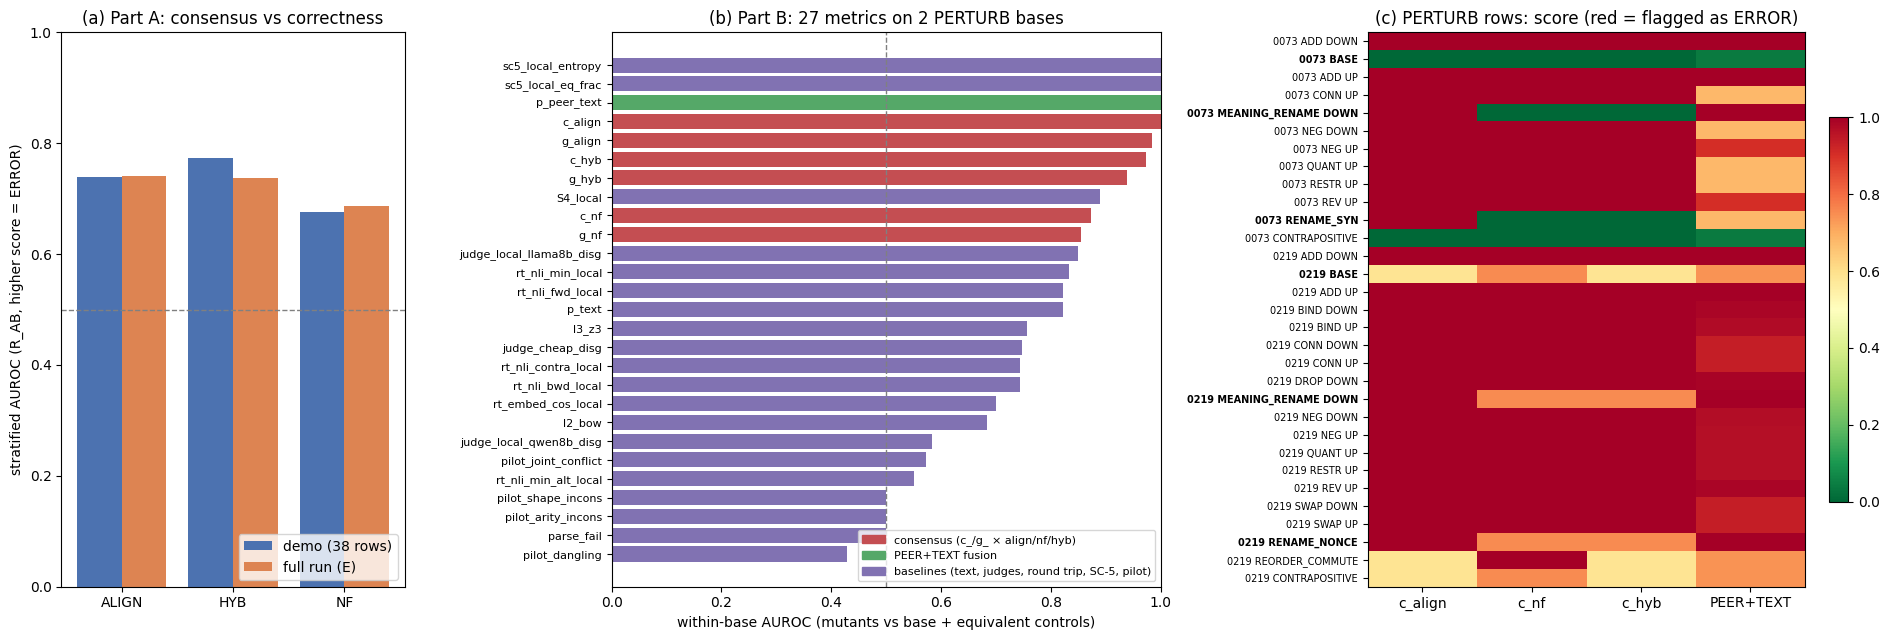

=== summary ===
selection: NEITHER ELIGIBLE: no rename-invariant consensus exists here; both reported as failed; the R_COMP read uses ALIGN.
E (demo) AUROC  ALIGN 0.739 | HYB 0.773 | NF 0.676   (full: 0.741 | 0.738 | 0.686)
PERTURB (demo) top-5 within-base AUROC: c_align 1.00, p_peer_text 1.00, sc5_local_eq_frac 1.00, sc5_local_entropy 1.00, g_align 0.98
full run within-base AUROC: PEER+TEXT 0.948, c_align 0.866, c_hyb 0.847, p_text 0.845, l3 0.816, c_nf 0.785


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), gridspec_kw={"width_ratios": [1, 1.6, 1.4]})

# (a) E AUROC: demo vs full run
ax = axes[0]
ms = ["c_score_align", "c_score_hyb", "c_score_nf"]
x = np.arange(len(ms))
ax.bar(x - 0.2, [auc_demo[m] for m in ms], 0.4, label=f"demo ({len(e_rows)} rows)", color="#4C72B0")
ax.bar(x + 0.2, [full_map[m] for m in ms], 0.4, label="full run (E)", color="#DD8452")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_xticks(x, ["ALIGN", "HYB", "NF"])
ax.set_ylim(0, 1)
ax.set_ylabel("stratified AUROC (R_AB, higher score = ERROR)")
ax.set_title("(a) Part A: consensus vs correctness")
ax.legend(loc="lower right")

# (b) PERTURB within-base AUROC of all metrics
ax = axes[1]
order = sorted([m for m in MET_B if not math.isnan(wb_auc[m])], key=lambda m: wb_auc[m])
cols = ["#C44E52" if m in ("c_align", "c_nf", "c_hyb", "g_align", "g_nf", "g_hyb") else
        "#55A868" if m in ("p_peer_text",) else "#8172B2" for m in order]
ax.barh(order, [wb_auc[m] for m in order], color=cols)
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.set_xlim(0, 1)
ax.set_xlabel("within-base AUROC (mutants vs base + equivalent controls)")
ax.set_title(f"(b) Part B: 27 metrics on {len(_p_bases)} PERTURB bases")
ax.tick_params(axis="y", labelsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#C44E52", label="consensus (c_/g_ × align/nf/hyb)"), Patch(color="#55A868", label="PEER+TEXT fusion"),
                   Patch(color="#8172B2", label="baselines (text, judges, round trip, SC-5, pilot)")], loc="lower right", fontsize=8)

# (c) heat map of consensus scores per PERTURB row
ax = axes[2]
labels, mat = [], []
for e in pert:
    lab = e["metadata_base_item_id"][:4] + " " + (e["metadata_operator"] or e["metadata_control_type"]) + \
          (" " + e["metadata_polarity"] if e["metadata_polarity"] else "")
    labels.append(lab)
    mat.append([val(e, m) for m in ("c_align", "c_nf", "c_hyb", "p_peer_text")])
im = ax.imshow(np.array(mat, float), aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
ax.set_xticks(range(4), ["c_align", "c_nf", "c_hyb", "PEER+TEXT"])
ax.set_yticks(range(len(labels)), labels, fontsize=7)
for i, lab in enumerate(labels):
    if "RENAME" in lab or "BASE" in lab:
        ax.get_yticklabels()[i].set_fontweight("bold")
ax.set_title("(c) PERTURB rows: score (red = flagged as ERROR)")
fig.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

print("=== summary ===")
print(f"selection: {data['selection']['note']}")
print(f"E (demo) AUROC  ALIGN {auc_demo['c_score_align']:.3f} | HYB {auc_demo['c_score_hyb']:.3f} | NF {auc_demo['c_score_nf']:.3f}   "
      f"(full: 0.741 | 0.738 | 0.686)")
top = sorted(MET_B, key=lambda m: -np.nan_to_num(wb_auc[m]))[:5]
print("PERTURB (demo) top-5 within-base AUROC: " + ", ".join(f"{m} {wb_auc[m]:.2f}" for m in top))
print("full run within-base AUROC: PEER+TEXT 0.948, c_align 0.866, c_hyb 0.847, p_text 0.845, l3 0.816, c_nf 0.785")